Distance algorithms from Baker textbook

Yair Franco, 2026

In [19]:
import time
import numpy as np
import matplotlib.pyplot as plt
from distance_helpers import Distances, gen_rand_points, gen_surface_grid

Create points to measure distances from:

In [ ]:
d = Distances()
# my usual SeisSol simulation parameters
# can also be initialized with these arguments: 'Distances(strike=0,...)'
# sometimes this syntax can be more useful for mapping multiple scenarios
d.strike = 0
d.dip = 60
d.fault_length = 30
d.fault_width = 15
d.hyp_depth = 10.5
d.hyp_along_strike = 15
d.ztor = 0

#generates points around origin (radial limit approx. 10km)
points = gen_rand_points(1000)

#generates a 50x50 km grid divided with 100 points per side
gridx, gridy = (50,50)
resx, resy = (100,100)
map_points = gen_surface_grid(gridx,gridy,resx,resy)
print(map_points.shape)

(10000, 3)


Run distance calculations (and look at how fast it is!)

In [21]:
start = time.time()
rjbs = d.calc_Rjb(map_points)
rrups = d.calc_Rrup(map_points)
rxs = d.calc_Rx(map_points)
end = time.time()
print(rjbs.shape)
print(rjbs[:10])
print(f'Execution time: {round(end-start,5)} s for {(len(rjbs))} points')

(10000,)
[21.41590784 20.97062401 20.52810722 20.08854034 19.6521213  19.21906456
 18.78960258 18.36398759 17.94249333 17.52541714]
Execution time: 0.00117 s for 10000 points


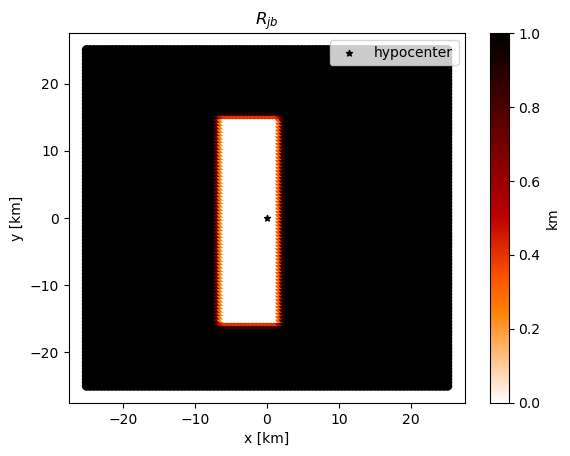

In [22]:
# it might also make sense to np.reshape 'rjbs', 'rrups', etc by (resx,resy) and plot with plt.imshow
# but it needs extra finagling to get the axes to show the right coordinates
jb = plt.scatter(map_points[:,0],map_points[:,1],c=rjbs, cmap='gist_heat_r')
plt.clim(0,1)
plt.colorbar(jb,label='km')
plt.scatter(0,0,s=20,marker='*',c='k',label='hypocenter')
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("$R_{jb}$")
plt.legend();

In [23]:
x_L = d.hyp_along_strike / d.fault_length
x_W = (d.hyp_depth - d.ztor) / (d.fault_width * np.sin(np.radians(d.dip)))
print(f'Note how the hypocenter appears on the plot about {round(x_L*100,1)}% along strike and {round(x_W*100,1)}% along dip lengths within the plane')

Note how the hypocenter appears on the plot about 50.0% along strike and 80.8% along dip lengths within the plane


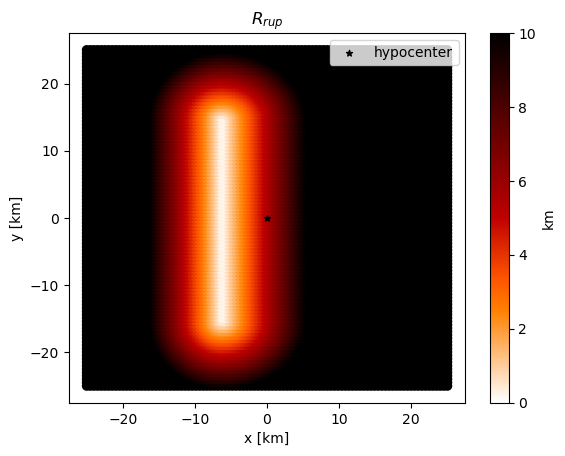

In [32]:
rup = plt.scatter(map_points[:,0],map_points[:,1],c=rrups, cmap='gist_heat_r')
plt.clim(0,10)
plt.colorbar(rup,label='km')
plt.scatter(0,0,s=20,marker='*',c='k',label='hypocenter')
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.legend()
plt.title("$R_{rup}$");

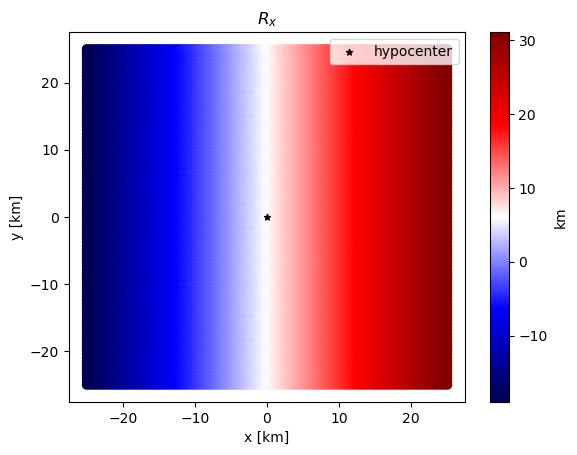

In [25]:
xs = plt.scatter(map_points[:,0],map_points[:,1],c=rxs, cmap='seismic')
plt.colorbar(xs,label='km')
plt.scatter(0,0,s=20,marker='*',c='k',label='hypocenter')
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.legend()
plt.title("$R_x$");

### If your coordinates are already (n,e,z)-formatted (instead of (x,y,z), which is analogous to (e,n,z)), then set convert_xyz to False (by default it is True).

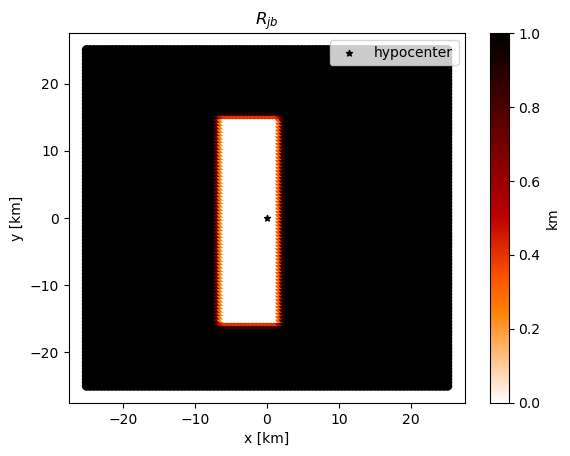

In [26]:
# convert points to (n,e,z)
# this is for the sake of example, as the functions do this part automatically
pnez = d.points_nez(map_points)

# override default convert_xyz and set to False
test = d.calc_Rjb(pnez,convert_xyz=False)

jb = plt.scatter(map_points[:,0],map_points[:,1],c=test, cmap='gist_heat_r')
plt.clim(0,1)
plt.colorbar(jb,label='km')
plt.scatter(0,0,s=20,marker='*',c='k',label='hypocenter')
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("$R_{jb}$")
plt.legend();

### If ommitted by mistake, the coordinates and calculations will be incorrect.

The effect is much more obvious when strike is not 0.

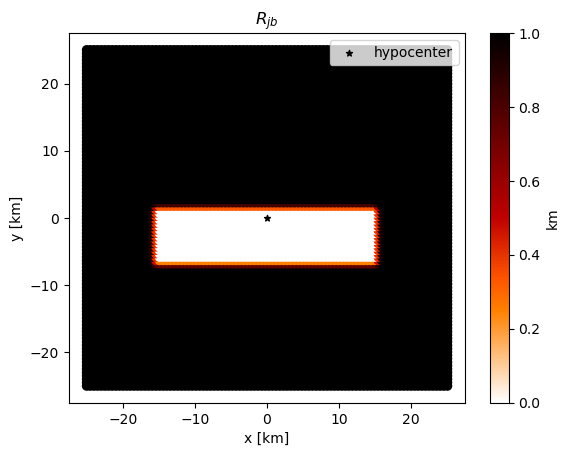

In [27]:
# map_points is in (x,y,z) and needs to be converted, but is not here
incorrect_method = d.calc_Rjb(map_points,convert_xyz=False)

jb = plt.scatter(map_points[:,0],map_points[:,1],c=incorrect_method, cmap='gist_heat_r')
plt.clim(0,1)
plt.colorbar(jb,label='km')
plt.scatter(0,0,s=20,marker='*',c='k',label='hypocenter')
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("$R_{jb}$")
plt.legend();

## For fun: 
testing np.clip() to simplify point distance logic syntax (apparently it's faster too)

In [34]:
# print(points)
#get some random numbers
uu = points[:,0]
print(len(uu),"random numbers:",uu[:10],"...")

op1 = -15.5
op2 = 0.5
#do some operations on them similar to the ones in the distance functions
a = uu * op2 * (-2 * np.random.random() + 1) # for more randomness
b = (1-op2) * uu
 
#original scalar calculation with python syntax
t1 = [max(min(u,b[i]),a[i]) for i,u in enumerate(uu)]

#syntactically closest vectorized translation in numpy
t2 = np.maximum(np.minimum(uu,b),a)

#translation to np.clip (fastest)
#though note how b and a are written in a different order than before
t3 = np.clip(uu,a,b)

print("Boolean check to see that all computations are equivalent:")
print(f't1 and t2: {all(t1==t2)},\nt1 and t3: {all(t1==t3)},\nt2 and t3: {all(t2==t3)}\n')
print("t1 is not always equal to t3 so we should not be using np.clip()")
print("Luckily for these calculations the speed difference is negligible")

1000 random numbers: [-1631.7756186   -906.08938026 -3840.68617784 -4612.77610643
  2997.80384726  2906.37390578  -353.18889458 -3903.16397498
 -4686.57697488   773.78596426] ...
Boolean check to see that all computations are equivalent:
t1 and t2: True,
t1 and t3: False,
t2 and t3: False

t1 is not always equal to t3 so we should not be using np.clip()
Luckily for these calculations the speed difference is negligible
